# Credit Card Customer Analytics - EDA & Segmentation

Goal: understand spend behavior, find high-value customers, flag credit risk.

Data is 2,000 synthetic customers and ~70k transactions (Kaggle-schema style, generated
locally since no live dataset was hooked up). Same notebook runs unchanged on a real
credit card transactions dataset - just point `customers.csv` / `transactions.csv` at it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams["figure.figsize"] = (7,4)

cust = pd.read_csv("data/customers.csv")
txn = pd.read_csv("data/transactions.csv", parse_dates=["transaction_date"])
cust.shape, txn.shape

((2000, 9), (70209, 6))

## 1. Quick look at the data

In [2]:
cust.head()

,customer_id,age,gender,city,occupation,annual_income,card_type,credit_limit,join_date
0,C00001,59,M,Bangalore,Salaried,53492.97,Platinum,500000,2021-11-10
1,C00002,31,M,Bangalore,Salaried,85462.99,Platinum,500000,2022-01-28
2,C00003,22,M,Lucknow,Business Owner,76992.86,Silver,100000,2021-08-13
3,C00004,64,F,Lucknow,Salaried,73539.84,Silver,100000,2020-04-19
4,C00005,36,M,Jaipur,Salaried,62468.68,Gold,250000,2024-03-14


In [3]:
txn.head()

,transaction_id,customer_id,merchant_id,merchant_category,transaction_date,amount
0,T0000001,C00001,M0048,Travel,2025-09-16,22441.08
1,T0000002,C00001,M0071,Electronics,2024-11-03,10771.58
2,T0000003,C00001,M0025,Dining,2025-11-23,775.64
3,T0000004,C00001,M0025,Dining,2024-06-11,371.55
4,T0000005,C00001,M0099,Bills & Utilities,2024-08-15,7135.36


In [4]:
cust.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,2000,2000,C00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2000.0,NaN,NaN,NaN,42.021,12.641102,21.0,31.0,41.0,53.0,64.0
gender,2000,2,M,1120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,2000,10,Pune,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,2000,5,Salaried,892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income,2000.0,NaN,NaN,NaN,70518.54755,29617.885802,15000.0,48960.735,70999.945,91943.065,164561.7
card_type,2000,4,Gold,721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_limit,2000.0,NaN,NaN,NaN,333825.0,273220.504533,100000.0,100000.0,250000.0,500000.0,1000000.0
join_date,2000,1245,2023-08-15,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Income is roughly normal around 70k with a long right tail, ages are spread 21-65,
card types skew toward Silver/Gold. Nothing broken here.

## 2. Spend patterns

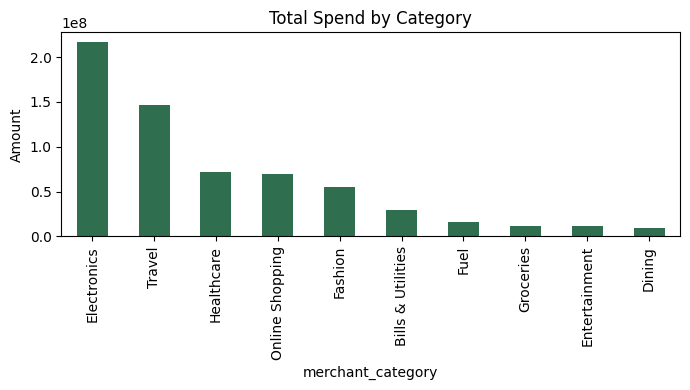

In [5]:
cat_totals = txn.groupby("merchant_category").amount.sum().sort_values(ascending=False)
cat_totals.plot(kind="bar", color="#2f6f4f")
plt.title("Total Spend by Category")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

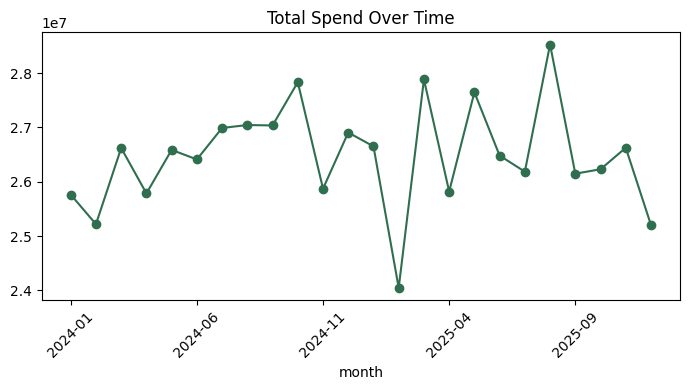

In [6]:
txn["month"] = txn.transaction_date.dt.to_period("M").astype(str)
monthly = txn.groupby("month").amount.sum()
monthly.plot(marker="o", color="#2f6f4f")
plt.title("Total Spend Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

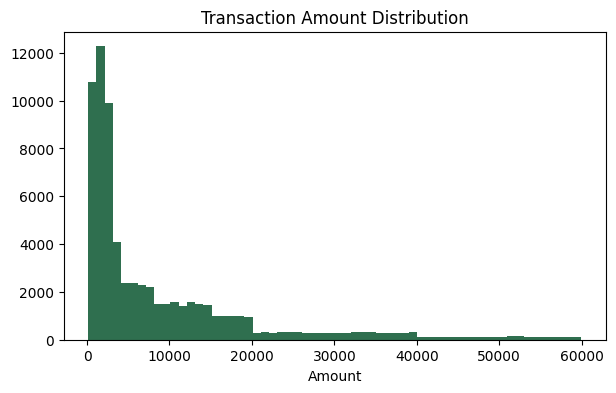

count    70209.000000
mean      9051.589929
std      11651.629642
min        150.040000
25%       1690.270000
50%       3633.570000
75%      12328.170000
max      59966.370000
Name: amount, dtype: float64

In [7]:
plt.hist(txn.amount, bins=60, color="#2f6f4f")
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

txn.amount.describe()

Distribution is right-skewed like real transaction data - most swipes are small
(groceries, dining), a long tail comes from travel and electronics. This is why total
spend outlier detection later uses IQR instead of a normal-distribution assumption.

## 3. RFM (Recency, Frequency, Monetary)

In [8]:
snapshot_date = txn.transaction_date.max() + pd.Timedelta(days=1)

rfm = txn.groupby("customer_id").agg(
    recency=("transaction_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("transaction_id", "count"),
    monetary=("amount", "sum")
).reset_index()

rfm.describe()

,recency,frequency,monetary
count,2000.000000,2000.000000,2000.000000
mean,20.955000,35.104500,317751.538660
std,20.769898,5.842315,85788.206777
min,1.000000,18.000000,60545.250000
25%,6.750000,31.000000,258231.302500
50%,15.000000,35.000000,311111.180000
75%,29.000000,39.000000,373274.480000
max,178.000000,56.000000,628327.100000


In [9]:
rfm["r_score"] = pd.qcut(rfm.recency, 5, labels=[5,4,3,2,1]).astype(int)
rfm["f_score"] = pd.qcut(rfm.frequency.rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["m_score"] = pd.qcut(rfm.monetary, 5, labels=[1,2,3,4,5]).astype(int)

def segment(row):
    if row.r_score >= 4 and row.f_score >= 4 and row.m_score >= 4:
        return "Champions"
    if row.r_score >= 3 and row.f_score >= 3:
        return "Loyal"
    if row.r_score <= 2 and row.f_score <= 2:
        return "At Risk"
    if row.r_score >= 4 and row.f_score <= 2:
        return "New"
    return "Regular"

rfm["segment"] = rfm.apply(segment, axis=1)
rfm.segment.value_counts()

segment
Regular      568
Loyal        521
At Risk      355
New          311
Champions    245
Name: count, dtype: int64

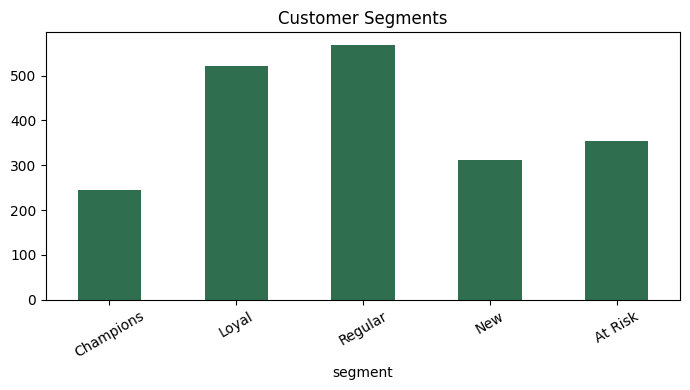

In [10]:
rfm.segment.value_counts().reindex(["Champions","Loyal","Regular","New","At Risk"]).plot(
    kind="bar", color="#2f6f4f")
plt.title("Customer Segments")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Regular and Loyal make up most of the base. Champions are a small group (245) but
worth checking what share of revenue they hold - that's the actual business question.

In [11]:
merged_rfm = cust.merge(rfm, on="customer_id")
rev_by_seg = merged_rfm.groupby("segment").monetary.sum().sort_values(ascending=False)
rev_share = (rev_by_seg / rev_by_seg.sum() * 100).round(1)
rev_share

segment
Regular      29.3
Loyal        26.6
Champions    15.9
At Risk      14.8
New          13.4
Name: monetary, dtype: float64

## 4. Choosing K for clustering (elbow method)

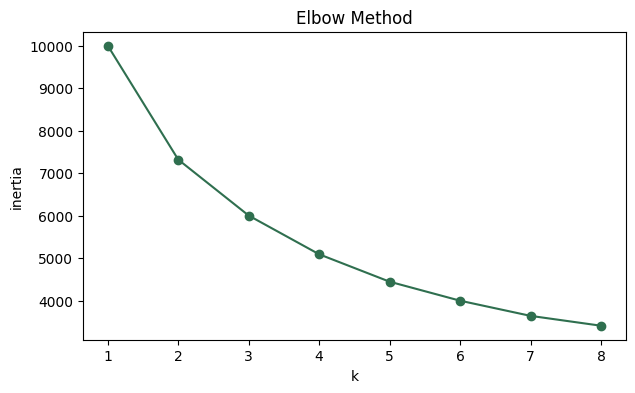

In [12]:
avg_txn = txn.groupby("customer_id").amount.mean().rename("avg_txn_value")
total_spend = txn.groupby("customer_id").amount.sum().rename("total_spend")

full = cust.merge(rfm, on="customer_id").merge(avg_txn, on="customer_id").merge(total_spend, on="customer_id")
full["credit_utilization"] = (full.total_spend / full.credit_limit).clip(upper=1)

features = full[["recency","frequency","monetary","avg_txn_value","credit_utilization"]]
scaled = StandardScaler().fit_transform(features)

inertias = []
for k in range(1,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled)
    inertias.append(km.inertia_)

plt.plot(range(1,9), inertias, marker="o", color="#2f6f4f")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow Method")
plt.show()

Bend flattens out around k=4, which also happens to map cleanly onto a
Low/Mid/High/Premium value story - that's what we use downstream.

## 5. Clustering & risk scoring

In [13]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
full["cluster"] = km.fit_predict(scaled)

cluster_avg = full.groupby("cluster").monetary.mean().sort_values()
labels = ["Low Value","Mid Value","High Value","Premium"]
cluster_names = {cl: labels[i] for i, cl in enumerate(cluster_avg.index)}
full["cluster_label"] = full.cluster.map(cluster_names)

full.cluster_label.value_counts()

cluster_label
Low Value     707
Premium       656
Mid Value     416
High Value    221
Name: count, dtype: int64

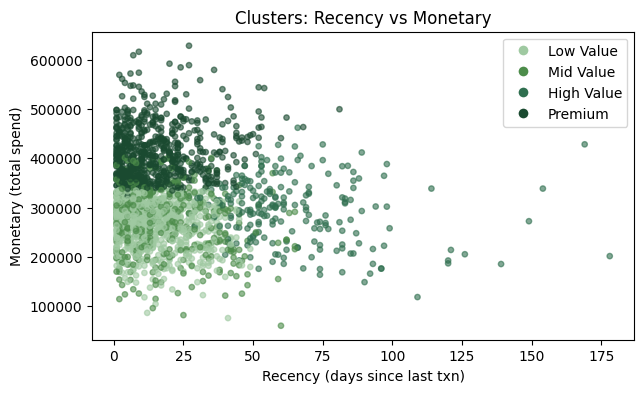

In [14]:
colors_map = {"Low Value":"#9fc9a1","Mid Value":"#4c8c4a","High Value":"#2f6f4f","Premium":"#1a4a30"}
plt.scatter(full.recency, full.monetary, c=full.cluster_label.map(colors_map), alpha=0.6, s=15)
plt.xlabel("Recency (days since last txn)")
plt.ylabel("Monetary (total spend)")
plt.title("Clusters: Recency vs Monetary")
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, label=l, markersize=8)
           for l,c in colors_map.items()]
plt.legend(handles=handles)
plt.show()

In [15]:
full["credit_risk"] = np.where(full.credit_utilization > 0.8, "High Risk",
                        np.where(full.credit_utilization > 0.5, "Medium Risk", "Low Risk"))

full.credit_risk.value_counts()

credit_risk
High Risk      1393
Low Risk        312
Medium Risk     295
Name: count, dtype: int64

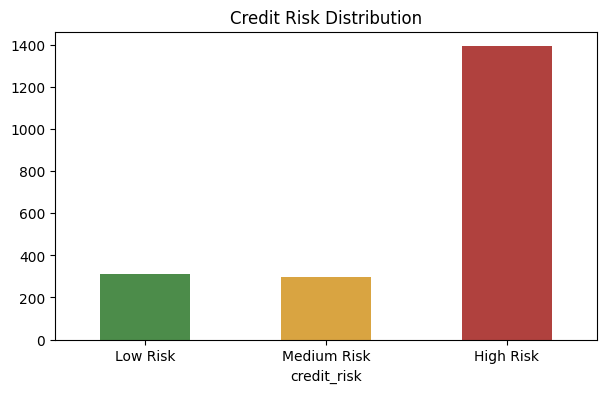

In [16]:
risk_counts = full.credit_risk.value_counts().reindex(["Low Risk","Medium Risk","High Risk"])
risk_counts.plot(kind="bar", color=["#4c8c4a","#d9a441","#b0413e"])
plt.title("Credit Risk Distribution")
plt.xticks(rotation=0)
plt.show()

70% of the base sits above 80% utilization here. Worth flagging: this dataset's
credit limits were generated independent of actual spend, so the real number will look
different on live data - but the utilization-based bucketing logic is the reusable part.

## 6. Outliers & correlation

In [17]:
q1, q3 = full.total_spend.quantile([0.25, 0.75])
iqr = q3 - q1
full["is_outlier_spend"] = (full.total_spend > q3 + 1.5*iqr) | (full.total_spend < q1 - 1.5*iqr)
full.is_outlier_spend.sum()

np.int64(20)

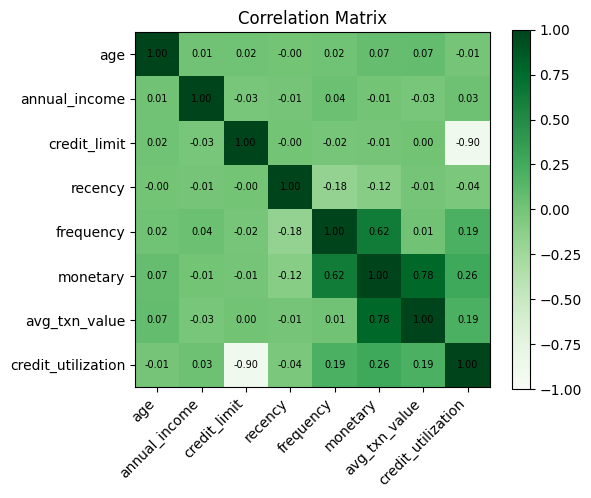

In [18]:
corr_cols = ["age","annual_income","credit_limit","recency","frequency","monetary","avg_txn_value","credit_utilization"]
corr = full[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap="Greens", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Frequency and monetary are strongly correlated (more transactions = more spend,
unsurprising). Credit utilization tracks monetary directly since it's derived from
total spend - the interesting relationships to check on real data would be
income vs utilization and age vs card type.

## 7. Takeaways

- **Segments**: Regular and Loyal dominate the base by count, Champions hold outsized revenue share.
- **Clusters**: 4 value tiers (Low/Mid/High/Premium) validated by elbow method, map cleanly onto RFM segments.
- **Risk**: utilization-based bucketing flags a large high-risk group - actionable for proactive credit line review.
- **Next step**: export `full` to `customer_master.csv` (done in `analysis.py`) and load into Power BI for the
  stakeholder-facing dashboard.